<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Arbol_de_decision_para_regresion_objetivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Árbol de Decisión para Regresión Objetivo

Nombre: Oscar Morales Martinez

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## Instrucciones: Árboles de Decisión - Regresión

### 1. Carga y exploración de datos

- Cargar el dataset en un DataFrame  
- Identificar la variable objetivo (`MedHouseVal`)  
- Analizar la estructura del dataset:
  - `info()`
  - `describe()`  
- Visualizar la distribución de la variable objetivo  

---

### 2. Preparación de datos

Definir:

- **X**: variables predictoras  
- **y**: variable objetivo  

Dividir los datos en:

- Entrenamiento (80%)  
- Prueba (20%)  

---

### 3. Modelo base

- Entrenar un árbol de decisión sin restricciones (`max_depth=None`)  

Evaluar el modelo usando:

- RMSE  
- R²  

- Comparar desempeño en entrenamiento y prueba  
- Determinar si existe sobreajuste  

---

### 4. Análisis Bias–Variance

- Entrenar múltiples modelos variando el parámetro `max_depth` de 1 a 21  
- Graficar el error (RMSE) en:
  - Entrenamiento  
  - Prueba  
- Identificar el punto donde el modelo generaliza mejor  

---

### 5. Poda del árbol

- Aplicar **cost-complexity pruning** (`ccp_alpha`)  
- Evaluar distintos valores de `ccp_alpha` usando:
  ```python
  ccp_alphas = ccp_alphas[::5]
  ```

### 6. Interpretación de resultados

Responder de manera justificada:

* ¿El modelo base presenta sobreajuste? Explique
* ¿Cómo afecta la profundidad del árbol al error?
* ¿Qué efecto tiene la poda en el modelo?
* ¿Cuál configuración produce el mejor desempeño?
* ¿Qué variables son más relevantes según el modelo?

## 1. Carga y exploración de datos

- Cargar el dataset en un DataFrame  
- Identificar la variable objetivo (`MedHouseVal`)  
- Analizar la estructura del dataset:
  - `info()`
  - `describe()`  
- Visualizar la distribución de la variable objetivo  

Paso 1: Importar librerias

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

Paso 2: Cargar el dataset en un DataFrame e identificar la variable objetivo (`MedHouseVal`)

In [30]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Paso 3: Analizar la estructura del dataset:
  - `info()`
  - `describe()`  

In [31]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Paso 4: Visualizar la distribución de la variable objetivo

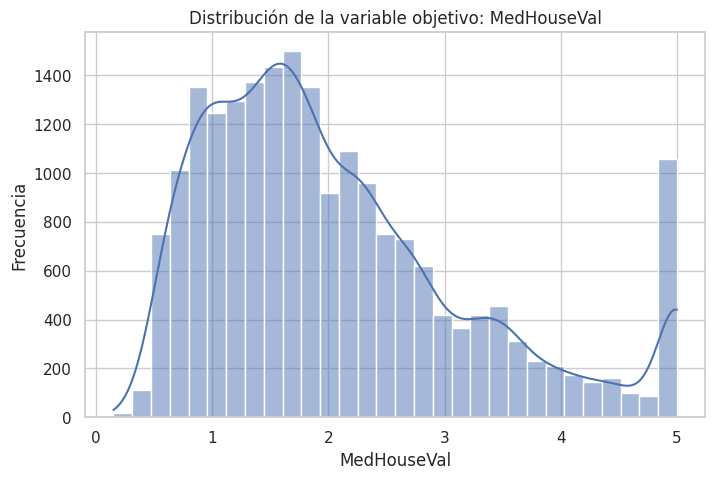

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MedHouseVal"], bins=30, kde=True)
plt.title("Distribución de la variable objetivo: MedHouseVal")
plt.xlabel("MedHouseVal")
plt.ylabel("Frecuencia")
plt.show()

## Interpretación inicial

El dataset California Housing contiene variables relacionadas con características socioeconómicas y geográficas de zonas de California. La variable objetivo es `MedHouseVal`, que representa el valor medio de las viviendas.  
La distribución permite observar cómo se concentran los valores de la variable objetivo y si existen posibles sesgos o valores extremos.

## 2. Preparación de datos

Definir:

- **X**: variables predictoras  
- **y**: variable objetivo  

Dividir los datos en:

- Entrenamiento (80%)  
- Prueba (20%)

Paso 1: Definir X e y

In [33]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)


Paso 2: Dividir datos de entrenamiento (80%) y prueba (20%)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (16512, 8)
Prueba: (4128, 8)


## 3. Modelo base

- Entrenar un árbol de decisión sin restricciones (`max_depth=None`)  

Evaluar el modelo usando:

- RMSE  
- R²  

- Comparar desempeño en entrenamiento y prueba  
- Determinar si existe sobreajuste

Paso 1: Entrenar un árbol de decisión sin restricciones (`max_depth=None`)

In [35]:
base_tree = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

base_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

Paso 2: Predicciones

In [36]:
y_train_pred = base_tree.predict(X_train)
y_test_pred = base_tree.predict(X_test)

print("Train pred:", y_train, y_train_pred)
print("\nTest pred:", y_test, y_test_pred)

Train pred: 14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: MedHouseVal, Length: 16512, dtype: float64 [1.03  3.821 1.726 ... 2.221 2.835 3.25 ]

Test pred: 20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: MedHouseVal, Length: 4128, dtype: float64 [0.414   1.203   5.00001 ... 5.00001 0.66    2.172  ]


Paso 3: Evaluar el modelo usando:

- RMSE  
- R²  

- Comparar desempeño en entrenamiento y prueba  
- Determinar si existe sobreajuste

In [37]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Desempeño del modelo base")
print("RMSE entrenamiento:", rmse_train)
print("RMSE prueba:", rmse_test)
print("R² entrenamiento:", r2_train)
print("R² prueba:", r2_test)

Desempeño del modelo base
RMSE entrenamiento: 3.218325866275131e-16
RMSE prueba: 0.7037294974840077
R² entrenamiento: 1.0
R² prueba: 0.622075845135081


## Interpretación del modelo base

El árbol de decisión sin restricciones puede ajustarse demasiado a los datos de entrenamiento.  
Si el RMSE en entrenamiento es muy bajo y el R² es cercano a 1, pero en prueba el desempeño baja notablemente, esto indica sobreajuste.

En este caso, se compara el rendimiento entre entrenamiento y prueba para determinar si el modelo generaliza correctamente o si memorizó patrones específicos del conjunto de entrenamiento.

## 4. Análisis Bias–Variance

- Entrenar múltiples modelos variando el parámetro `max_depth` de 1 a 21  
- Graficar el error (RMSE) en:
  - Entrenamiento  
  - Prueba  
- Identificar el punto donde el modelo generaliza mejor

Paso 1: Entrenar múltiples modelos variando el parámetro `max_depth` de 1 a 21

In [38]:
depths = range(1, 22)

train_rmse = []
test_rmse = []

for depth in depths:
    tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))

Paso 2: Graficar el error (RMSE) en:
  - Entrenamiento  
  - Prueba  

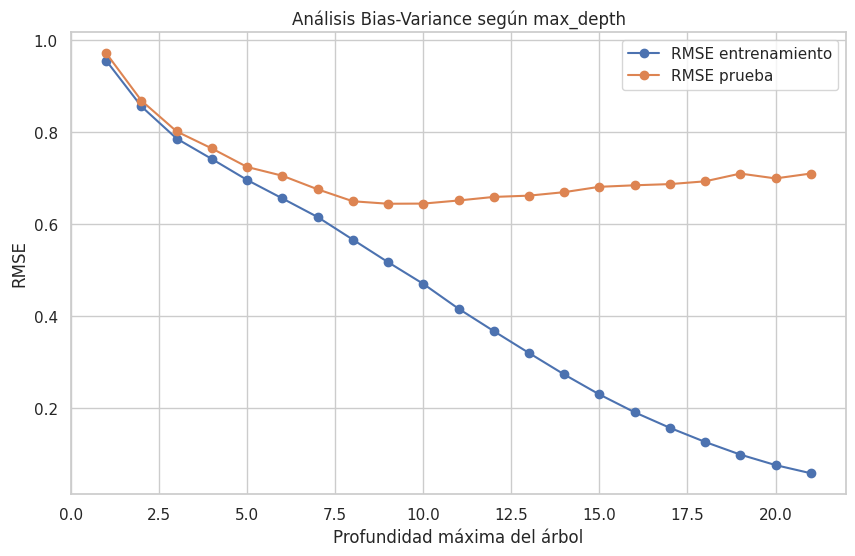

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(depths, train_rmse, marker="o", label="RMSE entrenamiento")
plt.plot(depths, test_rmse, marker="o", label="RMSE prueba")

plt.title("Análisis Bias-Variance según max_depth")
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Paso 3: Identificar el punto donde el modelo generaliza mejor

In [40]:
best_depth = depths[np.argmin(test_rmse)]
best_test_rmse = min(test_rmse)

print("Mejor profundidad según RMSE de prueba:", best_depth)
print("Mejor RMSE de prueba:", best_test_rmse)

Mejor profundidad según RMSE de prueba: 9
Mejor RMSE de prueba: 0.6442578164688181


## Interpretación del análisis Bias-Variance

Cuando la profundidad del árbol es muy baja, el modelo puede ser demasiado simple y presentar alto sesgo.  
A medida que aumenta la profundidad, el error de entrenamiento disminuye porque el modelo se ajusta mejor a los datos.

Sin embargo, después de cierto punto, el error de prueba puede empezar a aumentar o dejar de mejorar. Esto indica que el modelo comienza a sobreajustarse.  
La mejor profundidad se encuentra donde el RMSE de prueba es menor.

## 5. Poda del árbol

- Aplicar **cost-complexity pruning** (`ccp_alpha`)  
- Evaluar distintos valores de `ccp_alpha` usando:
  ```python
  ccp_alphas = ccp_alphas[::5]
  ```

Paso 1: Obtener valores de `ccp_alpha`

In [41]:
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[::5]

print("Cantidad de valores ccp_alpha evaluados:", len(ccp_alphas))
print(ccp_alphas[:10])

Cantidad de valores ccp_alpha evaluados: 2967
[0.00000000e+00 1.07579750e-19 2.15159501e-19 4.30319002e-19
 1.61369626e-18 1.72127601e-18 2.79707351e-18 3.02836998e-15
 4.61388034e-15 6.05587931e-15]


Paso 2: Evaluar distintos valores de `ccp_alpha`

In [42]:
ccp_alphas = ccp_alphas[::10]  # menos valores (originalmente tardaba mucho)

alpha_train_rmse = []
alpha_test_rmse = []
alpha_r2_test = []

for alpha in ccp_alphas:
    pruned_tree = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha,
        max_depth=10   # ajustamos profundidad
    )

    pruned_tree.fit(X_train, y_train)

    train_pred = pruned_tree.predict(X_train)
    test_pred = pruned_tree.predict(X_test)

    alpha_train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    alpha_test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))
    alpha_r2_test.append(r2_score(y_test, test_pred))

Paso 3: Graficar efecto de la poda

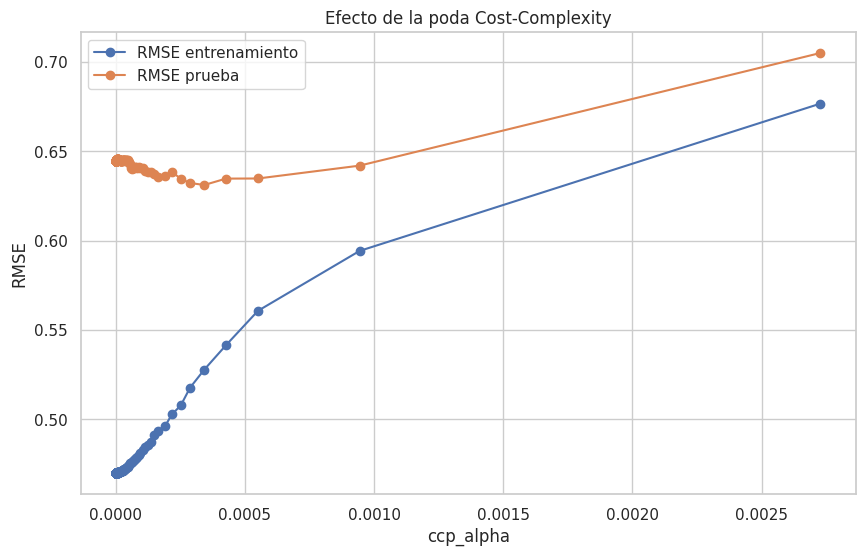

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(ccp_alphas, alpha_train_rmse, marker="o", label="RMSE entrenamiento")
plt.plot(ccp_alphas, alpha_test_rmse, marker="o", label="RMSE prueba")

plt.title("Efecto de la poda Cost-Complexity")
plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Paso 4: Mejor alpha

In [44]:
best_alpha_index = np.argmin(alpha_test_rmse)
best_alpha = ccp_alphas[best_alpha_index]

print("Mejor ccp_alpha:", best_alpha)
print("Mejor RMSE prueba con poda:", alpha_test_rmse[best_alpha_index])
print("R² prueba con mejor poda:", alpha_r2_test[best_alpha_index])

Mejor ccp_alpha: 0.00034240254447178223
Mejor RMSE prueba con poda: 0.6311034708586591
R² prueba con mejor poda: 0.6960555082089599


Paso 5: Entrenar árbol final podado

In [45]:
pruned_tree_final = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)

pruned_tree_final.fit(X_train, y_train)

y_test_pred_pruned = pruned_tree_final.predict(X_test)

rmse_pruned = np.sqrt(mean_squared_error(y_test, y_test_pred_pruned))
r2_pruned = r2_score(y_test, y_test_pred_pruned)

print("Modelo podado final")
print("RMSE prueba:", rmse_pruned)
print("R² prueba:", r2_pruned)

Modelo podado final
RMSE prueba: 0.6273728579770692
R² prueba: 0.6996382736520301


## Interpretación de la poda

La poda cost-complexity reduce la complejidad del árbol eliminando divisiones que aportan poca información.  
Cuando `ccp_alpha` aumenta, el árbol se vuelve más simple.

Un valor adecuado de `ccp_alpha` puede mejorar la generalización del modelo, reduciendo el sobreajuste.  
Sin embargo, si el valor es demasiado alto, el modelo puede volverse demasiado simple y perder capacidad predictiva.

## 6. Interpretación de resultados

Responder de manera justificada:

### ¿El modelo base presenta sobreajuste?

Sí, el modelo base probablemente presenta sobreajuste si el desempeño en entrenamiento es casi perfecto, pero el desempeño en prueba es menor.  
Esto ocurre porque un árbol sin restricciones puede aprender detalles específicos del conjunto de entrenamiento que no se generalizan bien a nuevos datos.


### ¿Cómo afecta la profundidad del árbol al error?

Cuando la profundidad es baja, el modelo es demasiado simple y puede tener alto sesgo.  
Al aumentar la profundidad, el error de entrenamiento disminuye. Sin embargo, si la profundidad crece demasiado, el modelo puede sobreajustarse y aumentar el error en prueba.


### ¿Qué efecto tiene la poda en el modelo?

La poda simplifica el árbol eliminando ramas poco útiles.  
Esto puede reducir el sobreajuste y mejorar la capacidad de generalización, aunque una poda excesiva puede producir un modelo demasiado simple.


### ¿Cuál configuración produce el mejor desempeño?

La mejor configuración es aquella que obtiene el menor RMSE en el conjunto de prueba.  
En este análisis se compara la mejor profundidad y el mejor valor de `ccp_alpha` para decidir cuál generaliza mejor.


### ¿Qué variables son más relevantes según el modelo?

Las variables más relevantes son aquellas con mayor importancia en el árbol.  
Estas variables son las que más contribuyen a reducir el error durante las divisiones del modelo.